Here, we scan and plot the Fano factors with temp on the y-axis and u on the x-axis. and consider three values of zeta = 0.5, 1.0, 2.0.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import math
import os
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from joblib import Parallel, delayed
from matplotlib.ticker import FixedLocator
import time

import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}" 
})

In [2]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"

ModelClass = formula.GaussianUpCrossings
mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

# Labels
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$ (Fano Factor)'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$ (Fano Factor)'
else:
    fano_label = r'$\mathrm{F}$ (Fano Factor)'

In [3]:
# Set simulation parameters
T = 20.0
omega0 = 1.0  # Fixed to 1.0
zeta_values = [0.5, 1.0, 2.0]  # Three values of zeta

In [4]:
# Parameter grids
num_points_temp = 250
temp_vals = torch.linspace(0.0, 2.0, num_points_temp)

num_points_u = 250
u_vals = torch.linspace(0.0, 2.0, num_points_u)

# Storage for results
mean_rates_all = {}
fano_factors_all = {}

In [5]:
# Compute function for parallel processing
def compute_point(i, j, current_temp, current_u, omega0, zeta, ModelClass, mean_rate_method, fano_method):
    """Calculates mean rate and Fano factor for a single parameter combination."""
    try:
        temp_val = current_temp.item() if isinstance(current_temp, torch.Tensor) else current_temp
        u = current_u
        model = ModelClass(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp_val, zeta=zeta, omega0=omega0)
        mr = getattr(model, mean_rate_method)()
        ff = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)
        return i, j, mr, ff
    except Exception as e:
        print(f"Error in worker for i={i}, j={j}: {e}")
        return i, j, float('nan'), float('nan')

# Loop through zeta values
for zeta in zeta_values:
    print(f"\nProcessing zeta = {zeta}")
    
    mean_rates = torch.zeros(num_points_temp, num_points_u)
    fano_factors = torch.zeros(num_points_temp, num_points_u)
    
    # Prepare tasks
    tasks = [(i, j, temp_vals[i], u_vals[j]) for i in range(num_points_temp) for j in range(num_points_u)]
    
    print(f"Starting parallel computation for {len(tasks)} points...")
    start_time = time.time() 
    
    # Execute in parallel
    results = Parallel(n_jobs=-1, verbose=1)(
        delayed(compute_point)(
            task[0], task[1], task[2], task[3], 
            omega0, zeta, ModelClass, mean_rate_method, fano_method 
        ) for task in tasks
    )
    
    end_time = time.time() 
    print(f"Parallel computation finished in {end_time - start_time:.2f} seconds.")
    
    # Process results
    for res in results:
        if res is not None:
            i, j, mr, ff = res
            mean_rates[i, j] = mr
            fano_factors[i, j] = ff
        else:
            print("Warning: A worker task returned None.")
    
    # Store results
    mean_rates_all[zeta] = mean_rates
    fano_factors_all[zeta] = fano_factors


Processing zeta = 0.5
Starting parallel computation for 62500 points...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 4368 tasks      | elapsed:   16.4s
[Parallel(n_jobs=-1)]: Done 12368 tasks      | elapsed:   31.9s
[Parallel(n_jobs=-1)]: Done 23568 tasks      | elapsed:   54.2s
[Parallel(n_jobs=-1)]: Done 37968 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 55568 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done 62500 out of 62500 | elapsed:  2.2min finished


Parallel computation finished in 129.90 seconds.

Processing zeta = 1.0
Starting parallel computation for 62500 points...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 312 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 5112 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 13112 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 24312 tasks      | elapsed:   37.9s
[Parallel(n_jobs=-1)]: Done 38712 tasks      | elapsed:   59.3s
[Parallel(n_jobs=-1)]: Done 56312 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 62500 out of 62500 | elapsed:  1.6min finished


Parallel computation finished in 95.16 seconds.

Processing zeta = 2.0
Starting parallel computation for 62500 points...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 2680 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 6680 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done 12280 tasks      | elapsed:   21.9s
[Parallel(n_jobs=-1)]: Done 19480 tasks      | elapsed:   35.4s
[Parallel(n_jobs=-1)]: Done 35704 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 56504 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 62500 out of 62500 | elapsed:  1.8min finished


Parallel computation finished in 110.08 seconds.


In [6]:
# Plotting parameters
axis_label_fontsize = 30
title_fontsize = 28
tick_label_fontsize = 28
num_x_ticks = 5
num_y_ticks = 5
tick_line_width = 2.0
spine_line_width = 2.0

# Colormaps
cmap_diverging = 'PRGn'
cmap_below_1 = 'Blues_r'
cmap_above_1 = 'Reds'

In [7]:
all_log_fano_values_list = []
for zeta_val in zeta_values:
    fano_data = fano_factors_all[zeta_val]
    fano_log = torch.log10(fano_data)
    all_log_fano_values_list.append(fano_log.cpu().numpy().flatten())

concatenated_logs = np.concatenate(all_log_fano_values_list)
global_log_min = np.nanmin(concatenated_logs)
global_log_max = np.nanmax(concatenated_logs)


# Create the global normalization
norm_global = mcolors.Normalize(vmin=global_log_min, vmax=global_log_max)

if (global_log_max - global_log_min) == 0:
    p_val_global = 0.5 # Middle point if range is zero
else:
    p_val_global = (0 - global_log_min) / (global_log_max - global_log_min)
p_val_global = np.clip(p_val_global, 1e-6, 1.0 - 1e-6) # Clip to be within (0,1)

base_cmap_obj_global = plt.get_cmap(cmap_diverging)
color_for_log_min_global = base_cmap_obj_global(0.0)
color_for_one_global = base_cmap_obj_global(0.5) # Color for Fano=1 (log_fano=0)
color_for_log_max_global = base_cmap_obj_global(1.0)

segmented_colors_global = [
    (0.0, color_for_log_min_global),
    (p_val_global, color_for_one_global),
    (1.0, color_for_log_max_global)
]
cmap_global = mcolors.LinearSegmentedColormap.from_list(
    "custom_global_fano_cmap", segmented_colors_global
)

Saving figures to: ../../figures/damped_harmonic_oscillator/fano_factor_upcrossing_multiple_zeta_omega0_1.00_temp_scan


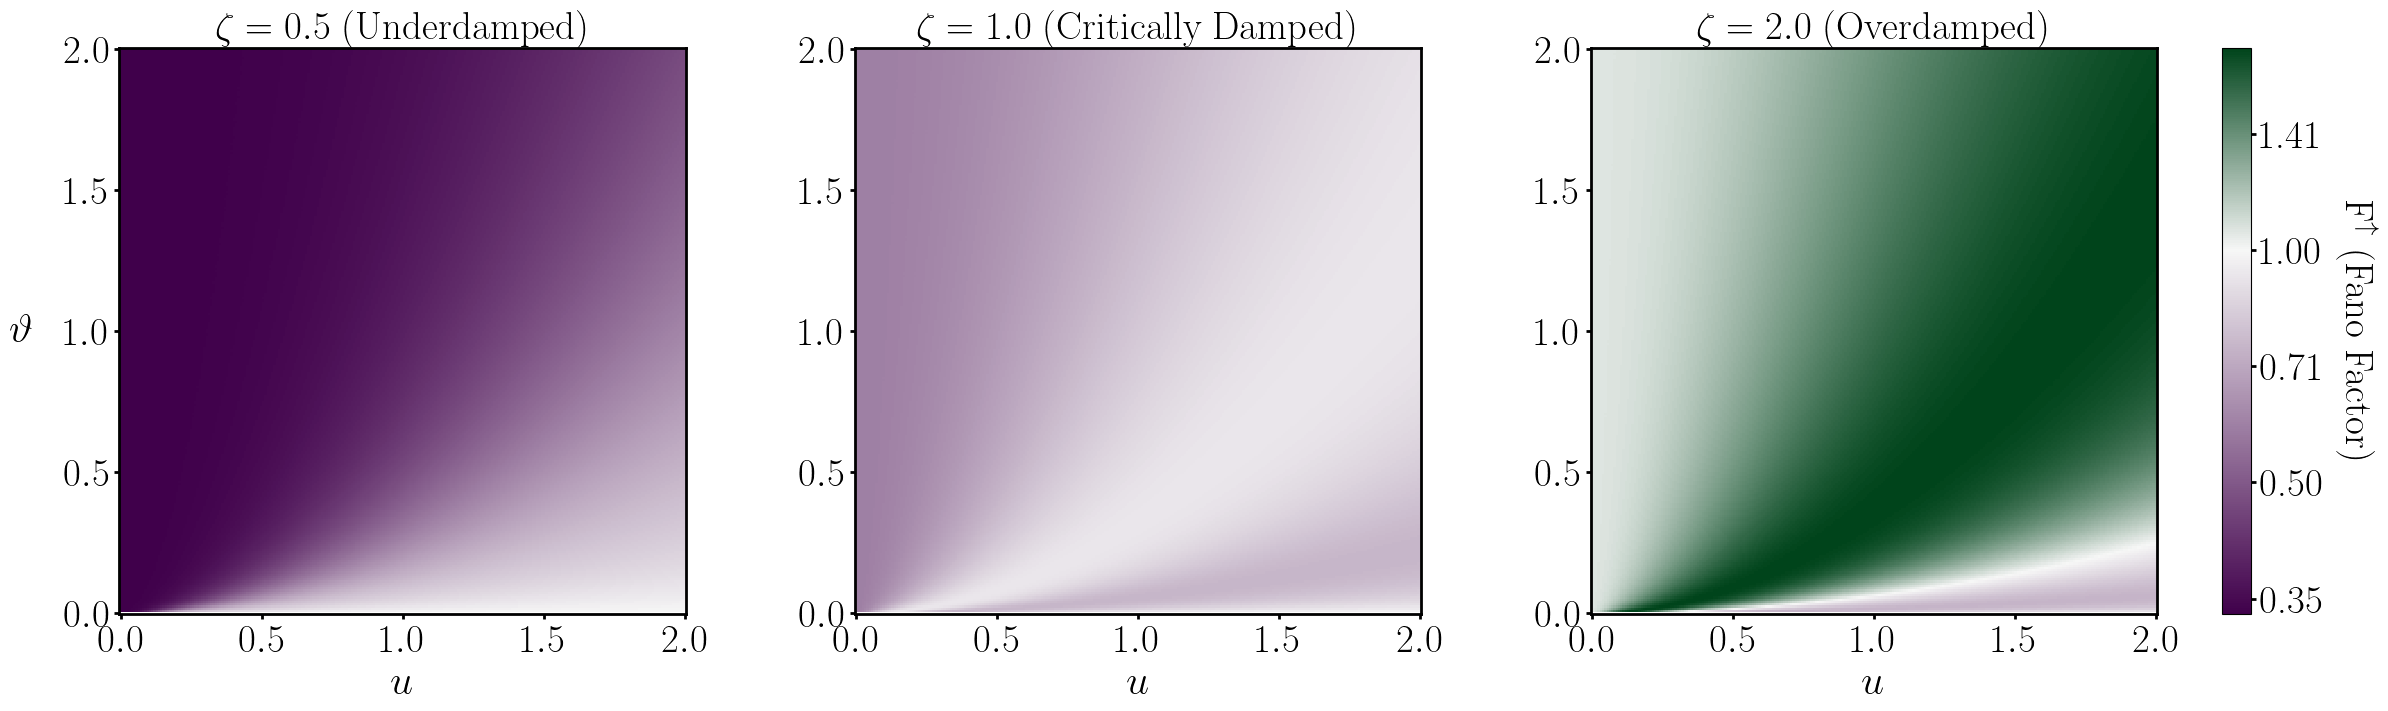

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)

pc_ref = None # To store a reference to one of the pcolormesh objects for the colorbar

# Plot Fano factors for each zeta value
for idx, zeta in enumerate(zeta_values):
    fano_factors = fano_factors_all[zeta]
    fano_log = torch.log10(fano_factors)
    fano_log_np = fano_log.cpu().numpy()

    # Plot using the global colormap and normalization
    pc = axes[idx].pcolormesh(u_vals, temp_vals, fano_log_np, shading='auto', cmap=cmap_global, norm=norm_global)
    axes[idx].set_box_aspect(1)
    if idx == (len(zeta_values) -1) : # Store the last pcolormesh for the global colorbar
        pc_ref = pc

    axes[idx].set_xlabel(r'$u$', fontsize=axis_label_fontsize)
    if idx == 0:
        axes[idx].set_ylabel(r'$\vartheta$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Adjusted labelpad

    # Set titles for subplots
    if idx == 0:
        axes[idx].set_title(rf'$\zeta = {zeta}$ (Underdamped)', fontsize=title_fontsize)
    elif idx == 1:
        axes[idx].set_title(rf'$\zeta = {zeta}$ (Critically Damped)', fontsize=title_fontsize)
    else:
        axes[idx].set_title(rf'$\zeta = {zeta}$ (Overdamped)', fontsize=title_fontsize)

    axes[idx].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
    axes[idx].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
    axes[idx].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

    for spine in axes[idx].spines.values():
        spine.set_linewidth(spine_line_width)

cbar = fig.colorbar(
        pc_ref,                       # the last pcolormesh
        ax=axes.ravel().tolist(),     # span *all* three panels
        location="right",             # stick it on the right
        fraction=0.046, pad=0.02)     # tweak width / gap
cbar.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_locs_fano_global = mticker.MaxNLocator(nbins=5).tick_values(global_log_min, global_log_max)
cbar.locator = FixedLocator(tick_locs_fano_global)
cbar.formatter = mticker.FuncFormatter(lambda x, pos: f"{10**x:.2f}") # Format ticks back to Fano scale
cbar.update_ticks()
cbar.set_label(fano_label, fontsize=tick_label_fontsize, rotation=270, labelpad=40) # Use the dynamic fano_label

# Save the figure
folder_loc = f'../../figures/damped_harmonic_oscillator/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'fano_factor_{crossing_type}_multiple_zeta_omega0_{omega0:.2f}_temp_scan' # Added suffix
file_save_path = os.path.join(folder_loc, file_name)

# Uncomment to save files:
print(f"Saving figures to: {file_save_path}")
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()